In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
df1 = pd.read_csv("data2/nytimes_economy_1.csv")

In [3]:
df2 = pd.read_csv("data2/nytimes_economy_2.csv")

In [4]:
df3 = pd.read_csv("data2/nytimes_economy_3.csv")

In [5]:
df4 = pd.read_csv("data2/nytimes_economy_4.csv")

In [6]:
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [7]:
df

,abstract,document_type,_id,keywords,news_desk,print_page,print_section,pub_date,section_name,snippet,...,headline.kicker,headline.print_headline,multimedia.caption,multimedia.credit,multimedia.default.url,multimedia.default.height,multimedia.default.width,multimedia.thumbnail.url,multimedia.thumbnail.height,multimedia.thumbnail.width
0,"The United States generated about 200,000 new ...",article,nyt://article/313ed1c5-243e-55ef-b28b-73dc8a67...,"[{'name': 'Subject', 'value': 'United States E...",Business/Financial Desk,00001,C,2006-01-07T05:00:00Z,Business,"The United States generated about 200,000 new ...",...,NaN,Bush Cites 2 Million New Jobs in 2005 and Heal...,NaN,NaN,NaN,0,0,NaN,0,0
1,"The Chinese statistics, showing a national eco...",article,nyt://article/2905419b-8fde-5d18-ad0e-3faf04a2...,"[{'name': 'Location', 'value': 'China', 'rank'...",Business / World Business,NaN,NaN,2006-01-25T05:00:00Z,Business,"The Chinese statistics, showing a national eco...",...,NaN,Chinese Economy Becomes 4th Largest in the World,NaN,NaN,NaN,0,0,NaN,0,0
2,Economic growth weakened unexpectedly in the f...,article,nyt://article/4bf669cc-a2f0-5b46-8880-b52fdba3...,"[{'name': 'Subject', 'value': 'United States E...",Business/Financial Desk,00001,C,2006-01-28T05:00:00Z,Business,Economic growth weakened unexpectedly in the f...,...,NaN,U.S. Economy Slowed Sharply at End of 2005,NaN,NaN,NaN,0,0,NaN,0,0
3,"The Chinese statistics, showing a national eco...",article,nyt://article/101dc4c1-0d6d-5620-916a-749fcc35...,"[{'name': 'Location', 'value': 'China', 'rank'...",Business / World Business,NaN,NaN,2006-01-25T05:00:00Z,Business,"The Chinese statistics, showing a national eco...",...,NaN,Chinese Economy Grows to 4th Largest in the World,NaN,NaN,NaN,0,0,NaN,0,0
4,Government statistics show China's economy gre...,article,nyt://article/fa267891-747c-5a32-8c29-ca2b6787...,"[{'name': 'Location', 'value': 'China', 'rank'...",Business/Financial Desk,00010,C,2006-01-25T05:00:00Z,Business,Government statistics show China's economy gre...,...,NaN,Economy in China Is No. 4 in World,NaN,NaN,NaN,0,0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12145,NaN,article,nyt://article/320274a7-7796-5913-8ee1-4f585113...,[],Business,NaN,NaN,2026-03-06T11:38:41Z,Business,NaN,...,NaN,NaN,"A gas station in Burgos, Spain, on Thursday. A...",Cesar Manso/Agence France-Presse — Getty Images,https://static01.nyt.com/images/2026/03/06/mul...,400,600,https://static01.nyt.com/images/2026/03/06/mul...,75,75
12146,"Jackson, Wyo., has long been a refuge for the ...",article,nyt://article/51c6a3c6-5f79-51bd-be49-582cc337...,"[{'name': 'Subject', 'value': 'High Net Worth ...",National,1.0,A,2026-03-02T10:00:23Z,U.S.,"Jackson, Wyo., has long been a refuge for the ...",...,BILLIONAIRE BOOM,Torrent of Money Transforms a Slice of Wyoming,"Jackson, Wyo. Teton County is both the richest...",Will Warasila for The New York Times,https://static01.nyt.com/images/2026/03/03/mul...,400,600,https://static01.nyt.com/images/2026/03/03/mul...,75,75
12147,The president still has a lot of leeway to imp...,article,nyt://article/27bc87f2-bfb1-58f5-a283-66a7c638...,"[{'name': 'Subject', 'value': 'United States P...",OpEd,NaN,NaN,2026-03-02T10:01:43Z,Opinion,The president still has a lot of leeway to imp...,...,Guest Essay,NaN,NaN,Abraham Lule,https://static01.nyt.com/images/2026/03/02/opi...,600,600,https://static01.nyt.com/images/2026/03/02/opi...,75,75
12148,Countries targeted by Iranian drones are eager...,article,nyt://article/3b89b962-a2ce-5c39-913d-f63a14b6...,"[{'name': 'Subject', 'value': 'Russian Invasio...",Foreign,NaN,NaN,2026-03-09T21:01:15Z,World,Countries targeted by Iranian drones are eager...,...,NaN,NaN,NaN,Brendan Hoffman for The New York Times,https://static01.nyt.com/images/2026/03/10/mul...,400,600,https://static01.nyt.com/images/2026/03/10/mul...,75,75


In [8]:
analyzer = SentimentIntensityAnalyzer()

In [9]:
# Choose the column containing the text
text_col = 'abstract'

# Drop rows with missing text
df = df.dropna(subset=[text_col, 'pub_date'])

# Compute sentiment
df = df.copy()
df['sentiment'] = df[text_col].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

In [10]:
df['pub_date'] = pd.to_datetime(df['pub_date'])
df['date'] = df['pub_date'].dt.date

In [11]:
daily_sentiment = df.groupby('date')['sentiment'].mean().reset_index()

In [12]:
daily_sentiment

,date,sentiment
0,2006-01-01,0.177750
1,2006-01-03,0.170425
2,2006-01-04,0.031700
3,2006-01-05,0.356600
4,2006-01-06,0.174800
...,...,...
5244,2026-03-05,-0.186700
5245,2026-03-06,-0.130592
5246,2026-03-07,-0.435750
5247,2026-03-08,0.278700


In [13]:
daily_sentiment.head(19)

,date,sentiment
0,2006-01-01,0.177750
1,2006-01-03,0.170425
2,2006-01-04,0.031700
3,2006-01-05,0.356600
4,2006-01-06,0.174800
5,2006-01-07,-0.008233
6,2006-01-08,0.112000
7,2006-01-09,0.690050
8,2006-01-10,0.000000
9,2006-01-11,0.000000


In [14]:
daily_sentiment.to_csv("data/sentiment_data.csv", index=True)

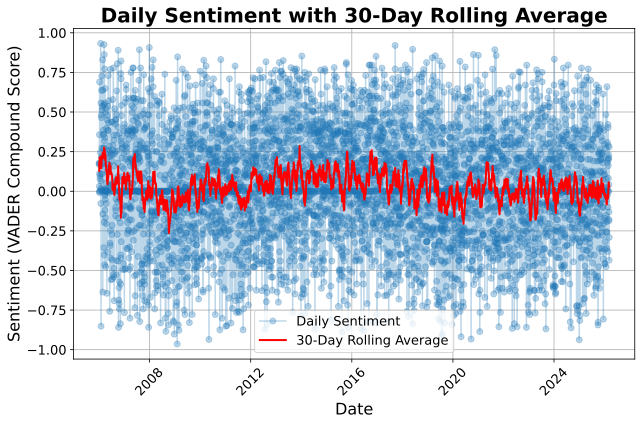

In [17]:
daily_sentiment['sentiment_30d'] = daily_sentiment['sentiment'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(9, 6))
plt.plot(daily_sentiment['date'], daily_sentiment['sentiment'], marker='o', linestyle='-', alpha=0.3, label='Daily Sentiment')
plt.plot(daily_sentiment['date'], daily_sentiment['sentiment_30d'], color='red', linewidth=2, label='30-Day Rolling Average')
plt.title('Daily Sentiment with 30-Day Rolling Average', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Sentiment (VADER Compound Score)', fontsize=16)
plt.xticks(rotation=45, fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig("results/sentiment.png", bbox_inches="tight")
plt.show()